In [1]:
# Cell 1 — Imports
import numpy as np
import pandas as pd
import xarray as xr
import sys
import matplotlib.pyplot as plt
from pathlib import Path
import glob
sys.path.append(str(Path("../src").resolve()))
from radar_lwc.preprocessing.chirps import combine_chirps
from radar_lwc.preprocessing.get_reflectivity import get_reflectivity
from radar_lwc.preprocessing.clean import drop_duplicate_times
from radar_lwc.preprocessing.align import align_to_reference_time

Load Both Radars

In [2]:
# Cell 2 — Load both
def load_rpg(folder):
    files = sorted(glob.glob(str(Path(folder) / "*ZEN.LV1.nc")))
    ds = xr.open_mfdataset(files, combine="by_coords")    # Combine="by_coords" orders them immediately by coordinates, in this case by the time so it is immediately in structure 7:01...7:02...7:03
    epoch = pd.Timestamp("2001-01-01")
    ds = ds.assign_coords(Time=("Time", epoch + pd.to_timedelta(ds.Time.values, unit="s")))
    ds = drop_duplicate_times(ds)
    return ds

ds_w  = load_rpg("../data/raw/cmtrace/20230928")
ds_ka = load_rpg("../data/raw/cmtrace/20230928_KaBand")

C:\Users\geron\AppData\Local\Temp\ipykernel_13392\2951657530.py:6: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ds = ds.assign_coords(Time=("Time", epoch + pd.to_timedelta(ds.Time.values, unit="s")))
C:\Users\geron\AppData\Local\Temp\ipykernel_13392\2951657530.py:6: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 

Reflectivities

In [3]:
# Cell 3 — Reflectivities
ze_w  = get_reflectivity(ds_w)
ze_ka = get_reflectivity(ds_ka)

Ranges and Time Coverage

In [4]:
# Cell 4 — Inspect ranges & time coverage  ← KEEP, condensed
print(f"W : {ze_w['range'].values[0]:.1f} → {ze_w['range'].values[-1]:.1f} m  ({ze_w.sizes['range']} gates)")
print(f"Ka: {ze_ka['range'].values[0]:.1f} → {ze_ka['range'].values[-1]:.1f} m  ({ze_ka.sizes['range']} gates)")
identical = np.allclose(ze_w['range'].values, ze_ka['range'].values)
print(f"Ranges identical: {identical}")

# Time coverage
print(f"\nW  : {ze_w.Time.values[0]}  →  {ze_w.Time.values[-1]}  ({ze_w.sizes['Time']} samples)")
print(f"Ka : {ze_ka.Time.values[0]}  →  {ze_ka.Time.values[-1]}  ({ze_ka.sizes['Time']} samples)")

# Temporal resolution
dt_ka = (ze_ka.Time.diff("Time") / np.timedelta64(1,"s")).median().values
dt_w  = (ze_w.Time.diff("Time")  / np.timedelta64(1,"s")).median().values
print(f"\nMedian Δt  W={dt_w:.1f}s   Ka={dt_ka:.1f}s")


W : 111.8 → 11974.8 m  (339 gates)
Ka: 111.8 → 11974.8 m  (339 gates)
Ranges identical: True

W  : 2023-09-28T07:00:04.000000000  →  2023-09-28T14:00:32.000000000  (10441 samples)
Ka : 2023-09-28T07:00:04.000000000  →  2023-09-28T14:00:32.000000000  (10520 samples)

Median Δt  W=1.0s   Ka=1.0s


In [5]:
missing_in_w = np.setdiff1d(ze_ka["Time"].values, ze_w["Time"].values)

print(f"Missing in W: {len(missing_in_w)} time steps")
print(missing_in_w)

Missing in W: 79 time steps
['2023-09-28T12:36:44.000000000' '2023-09-28T13:46:52.000000000'
 '2023-09-28T13:46:53.000000000' '2023-09-28T13:46:54.000000000'
 '2023-09-28T13:46:55.000000000' '2023-09-28T13:46:56.000000000'
 '2023-09-28T13:46:57.000000000' '2023-09-28T13:46:58.000000000'
 '2023-09-28T13:46:59.000000000' '2023-09-28T13:47:00.000000000'
 '2023-09-28T13:47:01.000000000' '2023-09-28T13:47:02.000000000'
 '2023-09-28T13:47:03.000000000' '2023-09-28T13:47:04.000000000'
 '2023-09-28T13:47:05.000000000' '2023-09-28T13:47:06.000000000'
 '2023-09-28T13:47:07.000000000' '2023-09-28T13:47:08.000000000'
 '2023-09-28T13:47:09.000000000' '2023-09-28T13:47:10.000000000'
 '2023-09-28T13:47:11.000000000' '2023-09-28T13:47:12.000000000'
 '2023-09-28T13:47:13.000000000' '2023-09-28T13:47:14.000000000'
 '2023-09-28T13:47:15.000000000' '2023-09-28T13:47:16.000000000'
 '2023-09-28T13:47:17.000000000' '2023-09-28T13:47:18.000000000'
 '2023-09-28T13:47:19.000000000' '2023-09-28T13:47:20.00000000

==================================================================================================================================================

ALIGN TIME

==================================================================================================================================================

In [6]:
# Cell 5 — Common time grid  --> If it is more then a little part that is missing for the time steps

# ze_w_c = align_to_reference_time(
    #da_ref=ze_ka,
    #da_target=ze_w,
    #method="nearest"
#)

#ze_ka_c = ze_ka

In [7]:
# Cell 6 — Range alignment (only if not identical)
#if not identical:
 # ze_ka_c = ze_ka_c.interp(range=ze_w_c["range"])

In [8]:
ze_ka_c = ze_ka.sel(Time=ze_w.Time)      # Both are set to the ze_w  time ; .sel selects only the data whose Time coordinates match the Time coordinates of ze_w.
ze_w_c = ze_w

In [9]:
# Cell 7 — Verify
print(f"After alignment: W={ze_w_c.shape}, Ka={ze_ka_c.shape}")
assert ze_w_c.shape == ze_ka_c.shape, "Shapes still don't match!"
print("✅ Aligned on common (time, range) grid")

After alignment: W=(10441, 339), Ka=(10441, 339)
✅ Aligned on common (time, range) grid


==================================================================================================================================================

PLOT

==================================================================================================================================================

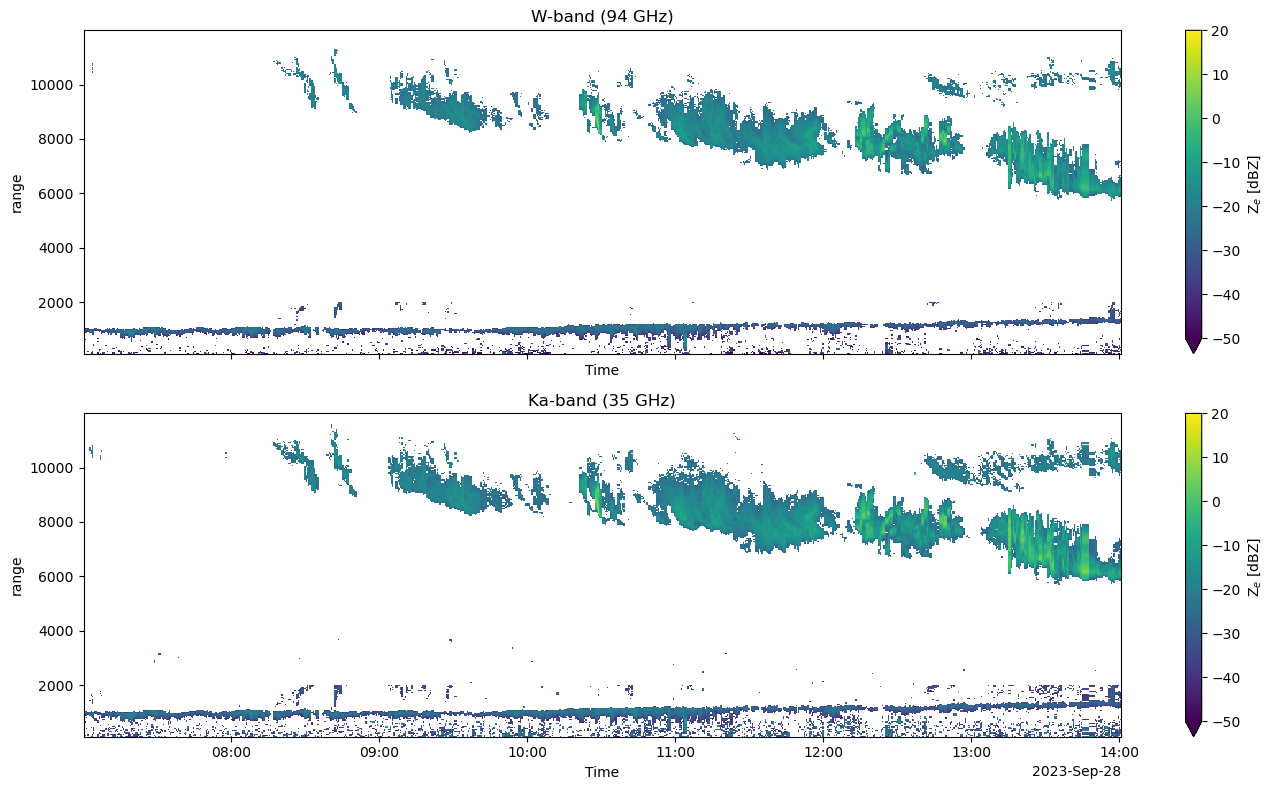

In [10]:
# Cell 8 — Side-by-side plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, sharey=True)
ze_w_c.plot(x="Time", y="range", ax=axes[0], cmap="viridis", vmin=-50, vmax=20, cbar_kwargs={"label": "Z$_e$ [dBZ]"})
axes[0].set_title("W-band (94 GHz)")
ze_ka_c.plot(x="Time", y="range", ax=axes[1], cmap="viridis", vmin=-50, vmax=20, cbar_kwargs={"label": "Z$_e$ [dBZ]"})
axes[1].set_title("Ka-band (35 GHz)")
plt.tight_layout()
plt.show()

(array([1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 1.0000e+00, 4.0000e+00, 3.0000e+00,
        4.0000e+00, 1.5000e+01, 5.0000e+00, 6.0000e+00, 1.1000e+01,
        1.9000e+01, 3.0000e+01, 3.3000e+01, 4.8000e+01, 1.2800e+02,
        3.9900e+02, 8.0400e+02, 1.3650e+03, 2.1560e+03, 3.0060e+03,
        3.9810e+03, 4.7200e+03, 5.5470e+03, 6.1360e+03, 6.5760e+03,
        7.2160e+03, 7.2030e+03, 7.2920e+03, 7.1780e+03, 7.0740e+03,
        6.7960e+03, 6.7490e+03, 6.6410e+03, 6.5770e+03, 6.8460e+03,
        6.8310e+03, 7.2410e+03, 8.0030e+03, 8.8160e+03, 9.9230e+03,
        1.1528e+04, 1.3329e+04, 1.5657e+04, 1.7927e+04, 1.9538e+04,
        2.0238e+04, 2.0058e+04, 1.8738e+04, 1.7327e+04, 1.6038e+04,
        1.4390e+04, 1.3583e+04, 1.2888e+04, 1.2159e+04, 1.1284e+04,
        1.0759e+04, 1.0105e+04, 9.6920e+03, 9.3920e+03, 8.5110e+03,
        7.7640e+03, 6.5390e+03, 5.2700e+03, 4.6230e+03, 3.8790e+03,
        3.5570e+03, 3.1360e+03, 2.8520e+03, 2.38

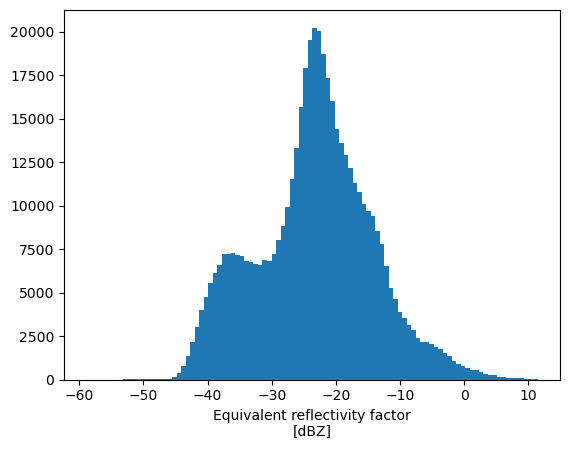

In [11]:
ze_ka.plot.hist(bins=100)

TEMPERATURE

In [12]:
T = ds_w["TProf"]                     # whatever the variable is named
print("Shape:", T.shape)                 # (Time, TAlt)?
print("Dims:", T.dims)
print("Min/Max:", float(T.min()), float(T.max()))
print("First profile (first time, all altitudes):")
print(T.isel(Time=0).values)
print("Altitude coord (if any):")
print(ds_w.coords)  # look for TAltLayer or similar


Shape: (10441, 93)
Dims: ('Time', 'TAlt')
Min/Max: 224.45999145507812 292.6600036621094
First profile (first time, all altitudes):
[289.46    289.395   289.2975  289.13498 288.9725  288.81    288.615
 288.41998 288.225   288.03    287.835   287.63998 287.44498 287.25
 287.055   286.86    286.66498 286.47    286.275   286.08    285.81998
 285.56    285.3     285.03998 284.78    284.52    284.25998 284.
 283.74    283.47998 283.22    282.96    282.69998 282.44    282.18
 281.91998 281.66    281.27    280.88    280.49    280.1     279.71
 279.31998 278.93    278.53998 278.15    277.75998 277.175   276.59
 275.35498 274.77    274.185   273.66498 273.21    272.56    271.91
 271.25998 270.61    269.96    269.31    268.66    268.00998 267.36
 266.71    265.735   264.75998 263.785   262.81    261.835   260.86
 259.88498 259.56    258.25998 256.96    255.65999 254.35999 253.06
 251.76    250.45999 248.51    246.56    244.60999 242.65999 240.70999
 238.76    236.81    234.85999 232.90999 230.959

==================================================================================================================================================

The T Profile Values are interpolated onto the Range grid. First we have to get the altitudes for the Temperature Profile in T_Alts, because Temperature Profile T_Prof only has Indices 1,2,3,.... Afterwards T_Prof uses T_Alts Altitudes and then the Values are interpolated onto the range grid

==================================================================================================================================================

In [13]:
# Physical altitude of radiometer profile
T_alts = ds_w["TAlts"].isel(Time=0).values
assert np.allclose(ds_w["TAlts"].values, T_alts), "TAlts varies in time!"   

# Tell xarray these are the heights of TProf  --> I give T_Prof new Altitude Values because it just as 1,2,3,4... as indice instead of actual heights
T_prof = ds_w["TProf"].assign_coords(TAlt=("TAlt", T_alts))

# Interpolate onto radar gates
T_on_range = T_prof.interp(
    TAlt=ze_w_c["range"],
    method="linear"
)

T_on_range.name = "T_cloud"

In [14]:
print(T_on_range.shape)                                # should match ze_w_c.shape
print(f"{float(T_on_range.min()):.1f} → {float(T_on_range.max()):.1f} °K")
# Expect roughly: -60 → +20 °C  for Cabauw autumn

(10441, 339)
224.6 → 291.9 °K


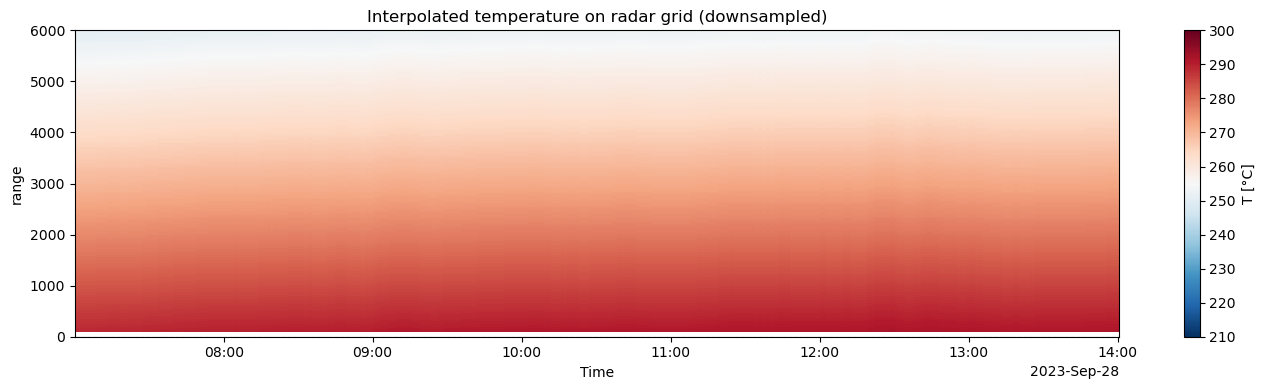

In [15]:

fig, ax = plt.subplots(1, 1, figsize=(14, 4))

T_on_range.isel(Time=slice(0, None, 5)).plot(
    x="Time",
    y="range",
    ax=ax,
    cmap="RdBu_r",
    vmin=210,
    vmax=300,
    cbar_kwargs={"label": "T [°C]"},
)

ax.axhline(0, ls="--", c="k", lw=0.8, alpha=0.5)
ax.set_ylim(0, 6000)
ax.set_title("Interpolated temperature on radar grid (downsampled)")

plt.tight_layout()
plt.show()


==================================================================================================================================================

SAVE DATA

==================================================================================================================================================

In [16]:
# Cell FINAL — Save aligned.nc
ds_out = xr.Dataset(
    {
        "Ze_W":    ze_w_c.rename("Ze_W"),
        "Ze_Ka":   ze_ka_c.rename("Ze_Ka"),
        "T_cloud": T_on_range,
    },
    attrs={
        "description": "Aligned W/Ka reflectivities + T field for LWC retrieval",
        "date": "20230928",
        "site": "Cabauw",
        "Ze_units": "dBZ",
        "created_by": "02_align.ipynb",
    }
)
out_path = Path("../data/processed/aligned.nc")
out_path.parent.mkdir(parents=True, exist_ok=True)
ds_out.to_netcdf(out_path)
print(f"Saved → {out_path}")
print(ds_out)


Saved → ..\data\processed\aligned.nc
<xarray.Dataset> Size: 43MB
Dimensions:  (Time: 10441, range: 339)
Coordinates:
  * Time     (Time) datetime64[ns] 84kB 2023-09-28T07:00:04 ... 2023-09-28T14...
  * range    (range) float32 1kB 111.8 134.2 156.5 ... 1.194e+04 1.197e+04
    TAlt     (range) float32 1kB 111.8 134.2 156.5 ... 1.194e+04 1.197e+04
Data variables:
    Ze_W     (Time, range) float32 14MB dask.array<chunksize=(78, 22), meta=np.ndarray>
    Ze_Ka    (Time, range) float32 14MB dask.array<chunksize=(77, 22), meta=np.ndarray>
    T_cloud  (Time, range) float32 14MB dask.array<chunksize=(78, 339), meta=np.ndarray>
Attributes:
    description:  Aligned W/Ka reflectivities + T field for LWC retrieval
    date:         20230928
    site:         Cabauw
    Ze_units:     dBZ
    created_by:   02_align.ipynb


In [18]:
print(type(ds_ka["Time"].values[0]))
print(ds_ka["Time"].dtype)

print(type(ds_w["Time"].values[0]))
print(ds_w["Time"].dtype)

<class 'numpy.datetime64'>
datetime64[ns]
<class 'numpy.datetime64'>
datetime64[ns]
